<a href="https://colab.research.google.com/github/jidatix/Latest-Project-Stroke-Prediction/blob/main/Latest_Project_Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install gradio imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import joblib
import gradio as gr
%matplotlib inline

In [4]:
# Load dataset
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

First 5 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1    

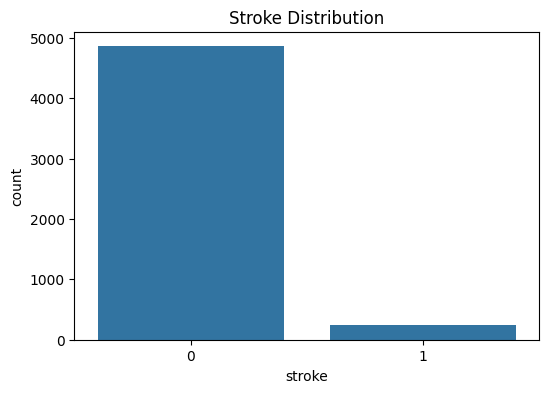

In [5]:
# Visualize target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df)
plt.title('Stroke Distribution')
plt.show()

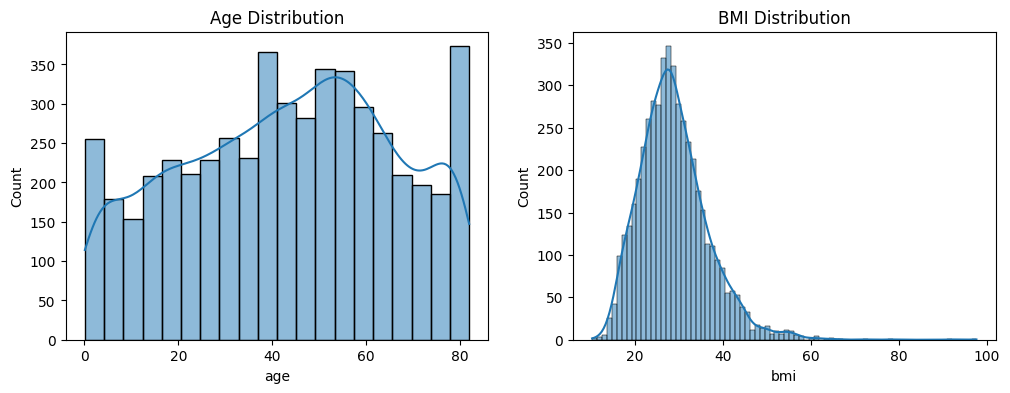

In [6]:
# Visualize numerical features
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['bmi'].dropna(), kde=True)
plt.title('BMI Distribution')
plt.show()

In [8]:
# Handle missing values
df['bmi'].fillna(df['bmi'].median(), inplace=True)  #  Impute BMI with median
df['smoking_status'].fillna('Unknown', inplace=True)

/tmp/ipython-input-2124654034.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)  # Example: Impute BMI with median
/tmp/ipython-input-2124654034.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [9]:
# Encode categorical variables
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['ever_married'] = le.fit_transform(df['ever_married'])
df['work_type'] = le.fit_transform(df['work_type'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])
df = pd.get_dummies(df, columns=['smoking_status'], drop_first=True)

In [10]:
# Drop irrelevant columns
df.drop('id', axis=1, inplace=True, errors='ignore')

In [11]:
# Split features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

In [12]:
# Standardize numerical features
scaler = StandardScaler()
X[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(X[['age', 'avg_glucose_level', 'bmi']])

In [13]:
# Apply SMOTE to balance data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

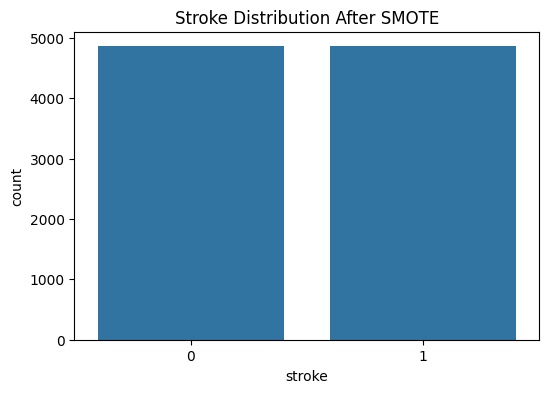

In [14]:
# Visualize balanced target
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled)
plt.title('Stroke Distribution After SMOTE')
plt.show()

In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (7777, 12)
Testing set shape: (1945, 12)


In [16]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# Train and evaluate models with cross-validation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=5)
    print(f"\n{name}:")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Cross-Validation Scores: {cv_scores}")
    print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression:
Test Accuracy: 0.7959
Cross-Validation Scores: [0.80411311 0.80308483 0.79475309 0.79938272 0.82510288]
Mean CV Score: 0.8053 (+/- 0.0209)
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       975
           1       0.77      0.84      0.80       970

    accuracy                           0.80      1945
   macro avg       0.80      0.80      0.80      1945
weighted avg       0.80      0.80      0.80      1945


Random Forest:
Test Accuracy: 0.9378
Cross-Validation Scores: [0.92956298 0.93727506 0.92901235 0.94444444 0.94753086]
Mean CV Score: 0.9376 (+/- 0.0151)
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       975
           1       0.91      0.97      0.94       970

    accuracy                           0.94      1945
   macro avg       0.94      0.94      0.94      1945
weighted avg       0.94      0.94      


Logistic Regression:
Test Accuracy: 0.7959
Cross-Validation Scores: [0.80411311 0.80359897 0.79475309 0.79938272 0.82510288]
Mean CV Score: 0.8054 (+/- 0.0208)
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       975
           1       0.77      0.84      0.80       970

    accuracy                           0.80      1945
   macro avg       0.80      0.80      0.80      1945
weighted avg       0.80      0.80      0.80      1945



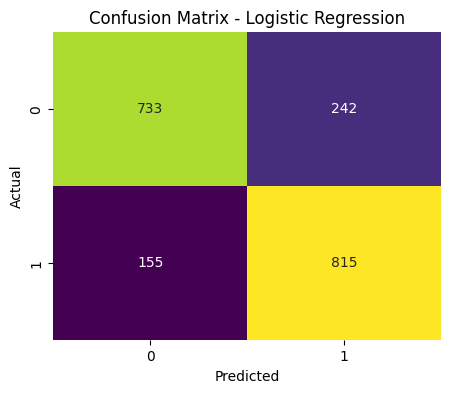


Random Forest:
Test Accuracy: 0.9378
Cross-Validation Scores: [0.92956298 0.93727506 0.92901235 0.94444444 0.94753086]
Mean CV Score: 0.9376 (+/- 0.0151)
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       975
           1       0.91      0.97      0.94       970

    accuracy                           0.94      1945
   macro avg       0.94      0.94      0.94      1945
weighted avg       0.94      0.94      0.94      1945



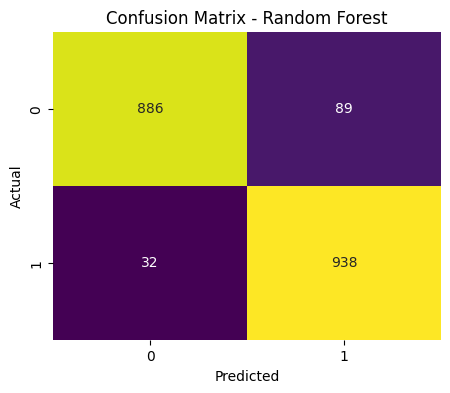

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:53:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:53:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:53:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:53:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:53:26] WARNING: /w


XGBoost:
Test Accuracy: 0.9368
Cross-Validation Scores: [0.9125964  0.9403599  0.93055556 0.95061728 0.94341564]
Mean CV Score: 0.9355 (+/- 0.0263)
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       975
           1       0.93      0.95      0.94       970

    accuracy                           0.94      1945
   macro avg       0.94      0.94      0.94      1945
weighted avg       0.94      0.94      0.94      1945



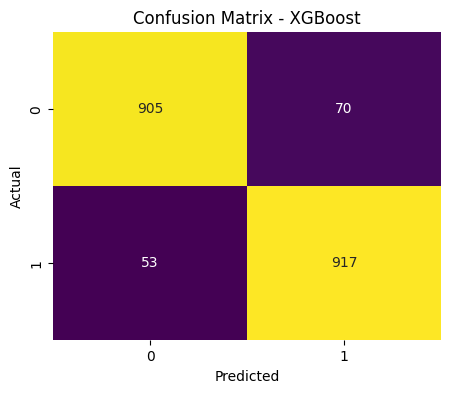

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Train and evaluate models with cross-validation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_resampled, y_resampled, cv=5)

    print(f"\n{name}:")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Cross-Validation Scores: {cv_scores}")
    print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # ==== Confusion Matrix ====
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [37]:
# Calculate training accuracy for Random Forest
rf_model = RandomForestClassifier(max_depth=5, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Reduced Complexity Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Training Accuracy:", train_accuracy)
print("Random Forest Test Accuracy:", 0.9378)  # من النتايج بتاعتك

Reduced Complexity Accuracy: 0.794344473007712
Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.9378


In [38]:
# Save the best model and scaler
joblib.dump(best_model, 'stroke_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [39]:
# Load model and scaler
model = joblib.load('stroke_prediction_model.pkl')
scaler = joblib.load('scaler.pkl')

# Define training columns (from X_resampled)
training_columns = X_resampled.columns.tolist()

# Define prediction function
def predict_stroke(age, gender, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status):
    try:
        # Create input DataFrame
        input_data = pd.DataFrame({
            'age': [float(age)],
            'gender': [1 if gender == 'Male' else 0],
            'hypertension': [1 if hypertension else 0],
            'heart_disease': [1 if heart_disease else 0],
            'ever_married': [1 if ever_married else 0],
            'work_type': [work_type],
            'Residence_type': [1 if Residence_type == 'Urban' else 0],
            'avg_glucose_level': [float(avg_glucose_level)],
            'bmi': [float(bmi)]
        })

        # Encode categorical variables (match training encoding)
        input_data = pd.get_dummies(input_data, columns=['work_type'], drop_first=True)

        # Handle smoking_status separately
        smoking_dummies = pd.get_dummies([smoking_status], prefix='smoking_status')
        input_data = pd.concat([input_data, smoking_dummies], axis=1)

        # Ensure all training columns are present
        for col in training_columns:
            if col not in input_data.columns:
                input_data[col] = 0
        input_data = input_data[training_columns]  # Reorder columns to match training

        # Scale numerical features
        input_data[['age', 'avg_glucose_level', 'bmi']] = scaler.transform(input_data[['age', 'avg_glucose_level', 'bmi']])

        # Make prediction
        prediction = model.predict(input_data)
        return "Stroke Likely" if prediction[0] == 1 else "No Stroke"
    except Exception as e:
        return f"Error: {str(e)}"

# Create Gradio interface
interface = gr.Interface(
    fn=predict_stroke,
    inputs=[
        gr.Number(label="Age"),
        gr.Radio(["Male", "Female"], label="Gender"),
        gr.Checkbox(label="Hypertension"),
        gr.Checkbox(label="Heart Disease"),
        gr.Checkbox(label="Ever Married"),
        gr.Dropdown(["Private", "Self-employed", "Govt_job", "Children", "Never_worked"], label="Work Type"),
        gr.Dropdown(["Urban", "Rural"], label="Residence Type"),
        gr.Number(label="Average Glucose Level"),
        gr.Number(label="BMI"),
        gr.Dropdown(["Never Smoked", "Formerly Smoked", "Smokes", "Unknown"], label="Smoking Status")
    ],
    outputs="text"
)

# Launch Gradio
interface.launch(share=True)  # Use share=True for public URL (may have limits in Colab)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1a9252e00063f0bf1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
